# Notebook 01: LLRF Data Overview Analysis (Updated for New Data)

## Overview

This notebook provides comprehensive overview of the LLRF anomaly detection dataset.

**Dataset**: 
- **7,427 events** (4,041 normal, 3,386 fault)
- **750 features** extracted from 8 LLRF signals
- **275 PCA components** (95% variance)
- **Data location**: `/sps/m4cast/_spiral2_data/_llrf_data/cooked_data/`

**Analysis Goals**:
1. Load and verify new dataset structure
2. Analyze fault type distribution
3. Examine temporal patterns
4. Visualize class balance and co-occurrence

---

**Author**: Updated by Claude  
**Date**: 2026-01-10  
**Version**: 2.0 (New dataset)

## 1. Setup and Imports

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports complete")

✓ Imports complete


## 2. Load New Dataset

**New Data Structure**:
- `features_engineered.pkl` (5.7GB): Contains features, sequences, and metadata
- `preprocessed_data.pkl` (2.0MB): Lightweight reference file

**Key Changes**:
- All data now in single comprehensive file
- Includes full signal sequences for deep learning
- 7,427 events (up from previous smaller batches)

In [2]:
# Define data path
DATA_DIR = Path('/sps/m4cast/_spiral2_data/_llrf_data/cooked_data')
FEATURES_FILE = DATA_DIR / 'features_engineered.pkl'
OUTPUT_DIR = DATA_DIR

print(f"Loading data from: {FEATURES_FILE}")
print(f"File size: {FEATURES_FILE.stat().st_size / (1024**3):.2f} GB")

# Load data
with open(FEATURES_FILE, 'rb') as f:
    data = pickle.load(f)

# Extract components
df_features = data['features_all']
feature_cols = data['feature_cols']
X_scaled = data['X_scaled']
X_pca = data['X_pca']
y_binary = data['y_binary']
Y_multilabel = data['y_multilabel']
signal_names = data['signal_names']
sequences_full = data.get('sequences_full', None)

# Define proper fault labels (in English)
FAULT_LABELS = [
    'Pickup threshold',                 # 0: Seuil pick-up
    'Fast external cutoff',              # 1: Coupure externe rapide
    'RF authorization absent',           # 2: Absence autorisation RF
    'Vacuum threshold',                  # 3: Seuil de vide
    'Cavity quench/breakdown',           # 4: Claquage ou quench cavité
    'RF safety threshold exceeded',      # 5: Dép seuil de sécurité RF
    'RF regulation out of tolerance'     # 6: Rég signal RF hors tolérance
]

# Use proper labels if available, otherwise fall back to loaded names
fault_names = FAULT_LABELS if len(FAULT_LABELS) == Y_multilabel.shape[1] else data['fault_column_names']

# Convert metadata to DataFrame
df_metadata = pd.DataFrame(data['metadata'])

# Derive additional metadata fields
if 'ALM' in df_metadata.columns:
    # is_automatic_trigger: True if ALM != '0x0000' (fault triggered automatically)
    df_metadata['is_automatic_trigger'] = df_metadata['ALM'].apply(
        lambda x: x != '0x0000' if isinstance(x, str) else x != 0
    )

if 'LOOP' in df_metadata.columns:
    # loop_closed: True if LOOP == 'ON'
    df_metadata['loop_closed'] = df_metadata['LOOP'].apply(
        lambda x: x.upper() == 'ON' if isinstance(x, str) else bool(x)
    )

print(f"\n✓ Dataset loaded successfully")
print(f"  Total events: {len(df_metadata):,}")
print(f"  Features: {len(feature_cols):,}")
print(f"  PCA components: {X_pca.shape[1]}")
print(f"  Signals: {len(signal_names)}")
print(f"  Fault types: {len(fault_names)}")
print(f"  Sequences shape: {sequences_full.shape if sequences_full is not None else 'N/A'}")

Loading data from: /sps/m4cast/_spiral2_data/_llrf_data/cooked_data/features_engineered.pkl
File size: 0.08 GB

✓ Dataset loaded successfully
  Total events: 4,509
  Features: 754
  PCA components: 247
  Signals: 27
  Fault types: 7
  Sequences shape: (4509, 1, 1)


## 3. Dataset Statistics

In [3]:
# Class balance
n_fault = y_binary.sum()
n_normal = (y_binary == 0).sum()
total = len(y_binary)

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"\nTotal Events: {total:,}")
print(f"  Normal events (ALM=0): {n_normal:,} ({100*n_normal/total:.1f}%)")
print(f"  Fault events (ALM>0):  {n_fault:,} ({100*n_fault/total:.1f}%)")
print(f"\nClass Ratio: {n_normal/n_fault:.2f}:1 (Normal:Fault)")

# Fault distribution
print(f"\n" + "=" * 70)
print("FAULT TYPE DISTRIBUTION")
print("=" * 70)
for i, fault_name in enumerate(fault_names):
    count = Y_multilabel[:, i].sum()
    pct = 100 * count / total
    print(f"  {fault_name:40s}: {count:4d} events ({pct:5.1f}%)")

# Multi-label statistics
n_faults_per_event = Y_multilabel.sum(axis=1)
single_fault = (n_faults_per_event == 1).sum()
multi_fault = (n_faults_per_event > 1).sum()

print(f"\n" + "=" * 70)
print("MULTI-LABEL CHARACTERISTICS")
print("=" * 70)
print(f"  Single fault events: {single_fault:,} ({100*single_fault/n_fault:.1f}% of faults)")
print(f"  Multi-fault events:  {multi_fault:,} ({100*multi_fault/n_fault:.1f}% of faults)")
print(f"  Average faults per fault event: {n_faults_per_event[y_binary==1].mean():.2f}")
print(f"  Max concurrent faults: {int(n_faults_per_event.max())}")

DATASET OVERVIEW

Total Events: 4,509
  Normal events (ALM=0): 3,324 (73.7%)
  Fault events (ALM>0):  1,185 (26.3%)

Class Ratio: 2.81:1 (Normal:Fault)

FAULT TYPE DISTRIBUTION
  Pickup threshold                        :   53 events (  1.2%)
  Fast external cutoff                    :    5 events (  0.1%)
  RF authorization absent                 :  674 events ( 14.9%)
  Vacuum threshold                        :   37 events (  0.8%)
  Cavity quench/breakdown                 :   22 events (  0.5%)
  RF safety threshold exceeded            :   29 events (  0.6%)
  RF regulation out of tolerance          :  521 events ( 11.6%)

MULTI-LABEL CHARACTERISTICS
  Single fault events: 1,029 (86.8% of faults)
  Multi-fault events:  156 (13.2% of faults)
  Average faults per fault event: 1.13
  Max concurrent faults: 2


## 4. Fault Distribution Visualization

✓ Saved: /sps/m4cast/_spiral2_data/_llrf_data/cooked_data/01_fault_distribution.png


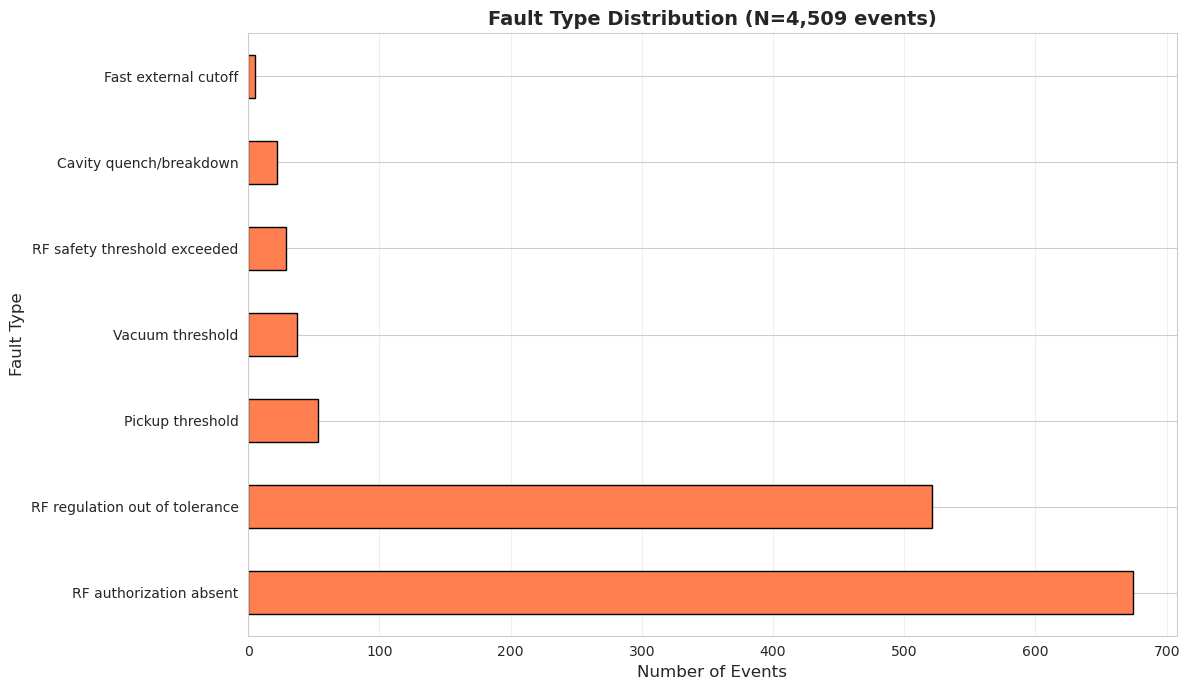

In [4]:
# Fault type bar chart
fault_counts = pd.Series({name: Y_multilabel[:, i].sum() for i, name in enumerate(fault_names)})
fault_counts = fault_counts.sort_values(ascending=False)

plt.figure(figsize=(12, 7))
ax = fault_counts.plot(kind='barh', color='coral', edgecolor='black')
plt.xlabel('Number of Events', fontsize=12)
plt.ylabel('Fault Type', fontsize=12)
plt.title(f'Fault Type Distribution (N={total:,} events)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

# Ensure labels are readable
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_fault_distribution.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / '01_fault_distribution.png'}")
plt.show()

## 5. Fault Co-occurrence Analysis

✓ Saved: /sps/m4cast/_spiral2_data/_llrf_data/cooked_data/01_fault_cooccurrence.png


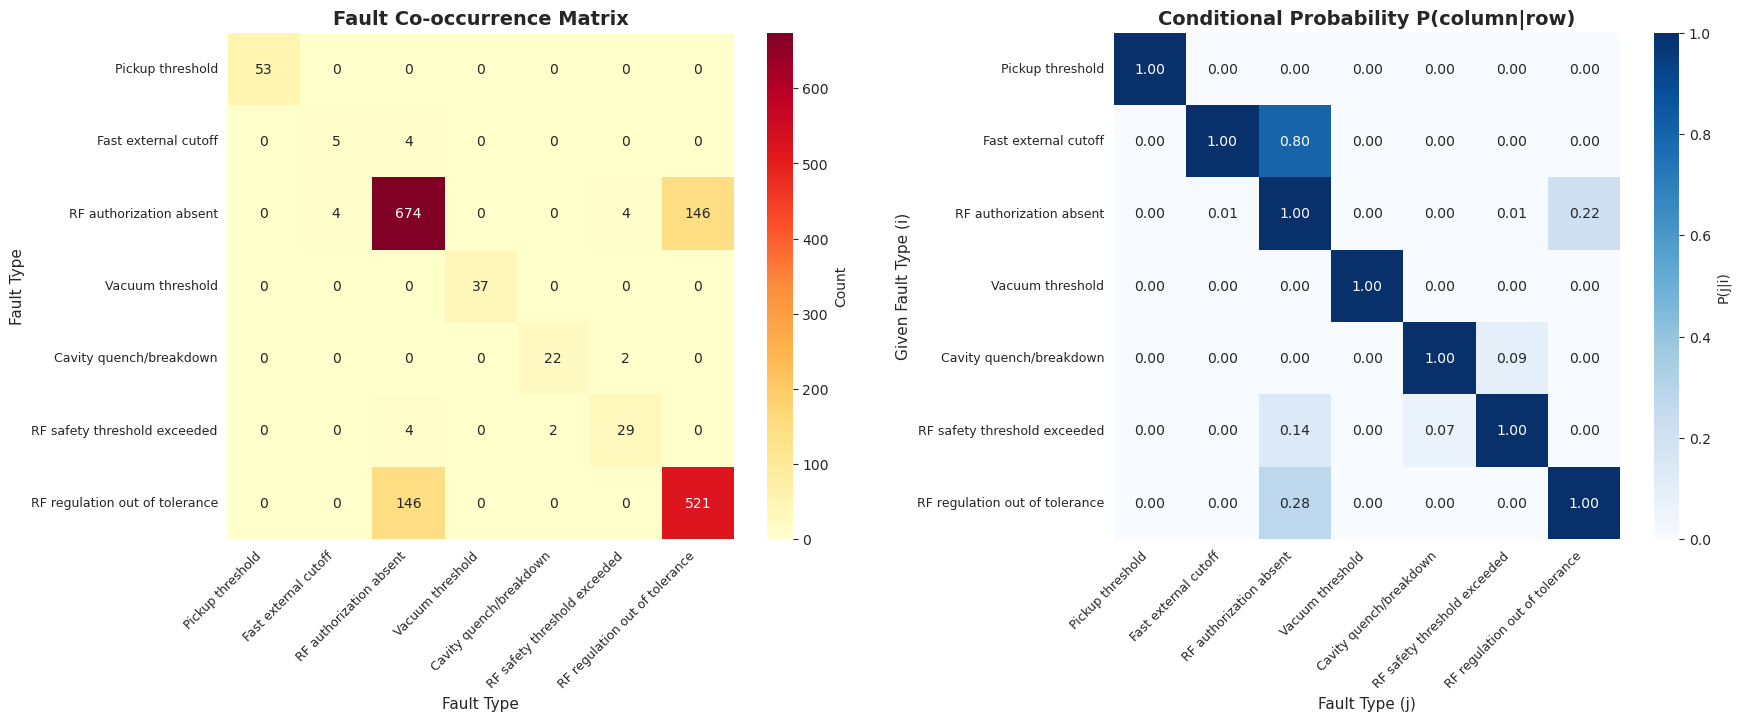

In [5]:
# Co-occurrence matrix
df_cooccur = pd.DataFrame(
    Y_multilabel.T @ Y_multilabel,
    index=fault_names,
    columns=fault_names
)

# Conditional probability P(j|i)
fault_totals = Y_multilabel.sum(axis=0)
df_cond_prob = df_cooccur.copy()
for i in range(len(fault_names)):
    if fault_totals[i] > 0:
        df_cond_prob.iloc[i, :] = df_cooccur.iloc[i, :] / fault_totals[i]
    else:
        df_cond_prob.iloc[i, :] = 0

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Co-occurrence heatmap
sns.heatmap(df_cooccur, annot=True, fmt='g', cmap='YlOrRd', ax=axes[0], 
            cbar_kws={'label': 'Count'}, square=True, 
            xticklabels=True, yticklabels=True)
axes[0].set_title('Fault Co-occurrence Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fault Type', fontsize=11)
axes[0].set_ylabel('Fault Type', fontsize=11)
axes[0].tick_params(axis='both', labelsize=9)
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
plt.setp(axes[0].get_yticklabels(), rotation=0)

# Conditional probability heatmap
sns.heatmap(df_cond_prob, annot=True, fmt='.2f', cmap='Blues', ax=axes[1], 
            cbar_kws={'label': 'P(j|i)'}, vmin=0, vmax=1, square=True,
            xticklabels=True, yticklabels=True)
axes[1].set_title('Conditional Probability P(column|row)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fault Type (j)', fontsize=11)
axes[1].set_ylabel('Given Fault Type (i)', fontsize=11)
axes[1].tick_params(axis='both', labelsize=9)
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
plt.setp(axes[1].get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_fault_cooccurrence.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR / '01_fault_cooccurrence.png'}")
plt.show()

## 6. Temporal Distribution Analysis

No Timestamp column found in metadata
Found DATE field, parsing timestamps...
Parsed 4509/4509 timestamps
Date range: 2019-09-23 14:55:09 to 2025-10-24 04:28:42
✓ Saved: /sps/m4cast/_spiral2_data/_llrf_data/cooked_data/01_temporal_distribution.png


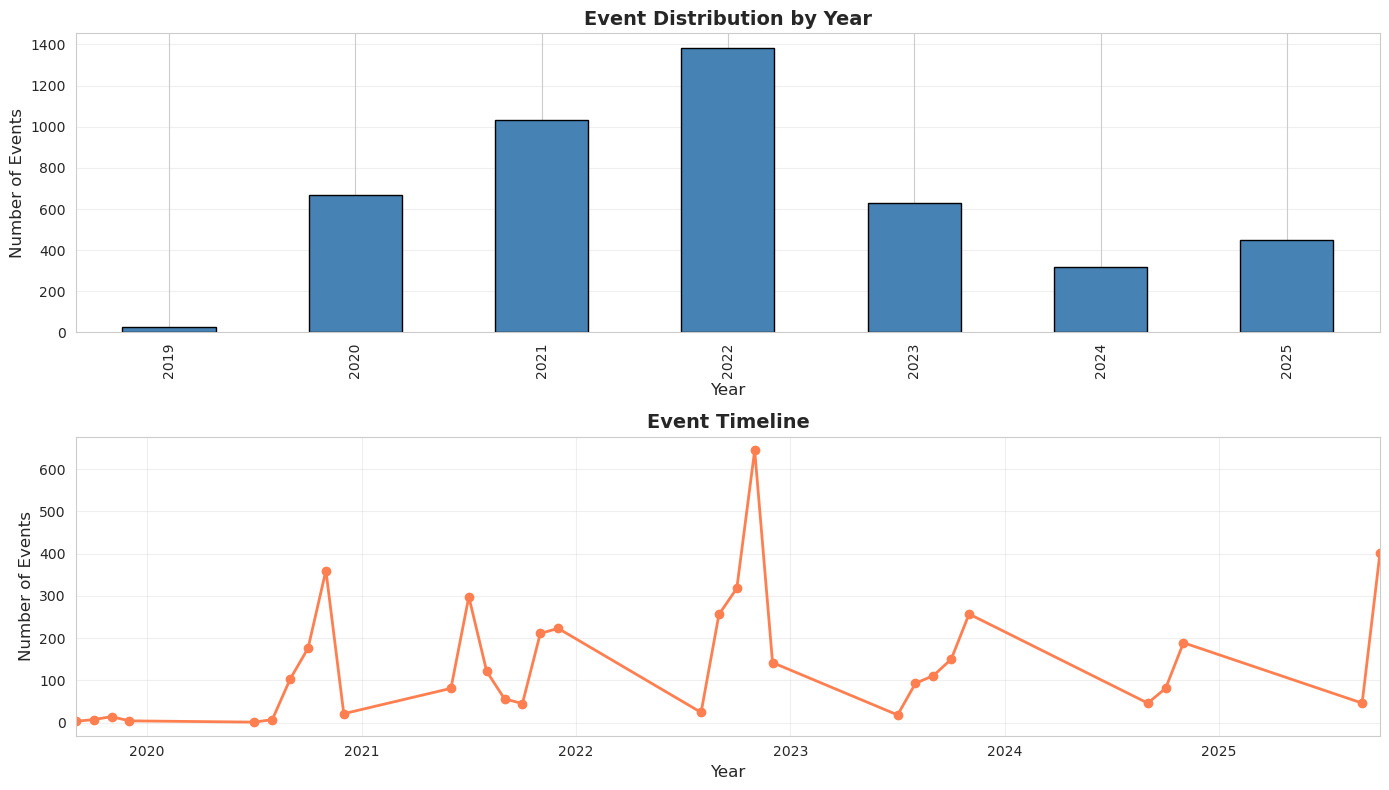

In [6]:
# Check if timestamp column exists in metadata
if 'Timestamp' in df_metadata.columns:
    df_metadata['Timestamp'] = pd.to_datetime(df_metadata['Timestamp'], errors='coerce')
    valid_timestamps = df_metadata['Timestamp'].notna().sum()
    
    print(f"Valid timestamps: {valid_timestamps}/{len(df_metadata)}")
    
    if valid_timestamps > 100:
        print(f"Date range: {df_metadata['Timestamp'].min()} to {df_metadata['Timestamp'].max()}")
        
        # Extract year and month
        df_metadata['Year'] = df_metadata['Timestamp'].dt.year
        df_metadata['Month'] = df_metadata['Timestamp'].dt.to_period('M')
        
        # Plot temporal distribution
        fig, axes = plt.subplots(2, 1, figsize=(14, 8))
        
        # Events by year
        year_counts = df_metadata['Year'].value_counts().sort_index()
        year_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
        axes[0].set_xlabel('Year', fontsize=12)
        axes[0].set_ylabel('Number of Events', fontsize=12)
        axes[0].set_title('Event Distribution by Year', fontweight='bold', fontsize=14)
        axes[0].grid(True, alpha=0.3, axis='y')
        
        # Timeline plot
        month_counts = df_metadata.groupby('Month').size().sort_index()
        month_counts.plot(ax=axes[1], color='coral', marker='o', linewidth=2)
        axes[1].set_xlabel('Year', fontsize=12)
        axes[1].set_ylabel('Number of Events', fontsize=12)
        axes[1].set_title('Event Timeline', fontweight='bold', fontsize=14)
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / '01_temporal_distribution.png', dpi=150, bbox_inches='tight')
        print(f"✓ Saved: {OUTPUT_DIR / '01_temporal_distribution.png'}")
        plt.show()
    else:
        print("Not enough valid timestamps for temporal analysis")
else:
    print("No Timestamp column found in metadata")
    
    # Check if DATE field exists for parsing
    if 'DATE' in df_metadata.columns:
        print("Found DATE field, parsing timestamps...")
        # DATE format is "OCT 29 2019 11:26:53" (uppercase month abbreviation)
        df_metadata['Timestamp'] = pd.to_datetime(df_metadata['DATE'], format="%b %d %Y %H:%M:%S", errors='coerce')
        valid_timestamps = df_metadata['Timestamp'].notna().sum()
        print(f"Parsed {valid_timestamps}/{len(df_metadata)} timestamps")
        
        if valid_timestamps > 100:
            print(f"Date range: {df_metadata['Timestamp'].min()} to {df_metadata['Timestamp'].max()}")
            
            # Extract year and month
            df_metadata['Year'] = df_metadata['Timestamp'].dt.year
            df_metadata['Month'] = df_metadata['Timestamp'].dt.to_period('M')
            
            # Plot temporal distribution
            fig, axes = plt.subplots(2, 1, figsize=(14, 8))
            
            # Events by year
            year_counts = df_metadata['Year'].value_counts().sort_index()
            year_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
            axes[0].set_xlabel('Year', fontsize=12)
            axes[0].set_ylabel('Number of Events', fontsize=12)
            axes[0].set_title('Event Distribution by Year', fontweight='bold', fontsize=14)
            axes[0].grid(True, alpha=0.3, axis='y')
            
            # Timeline plot
            month_counts = df_metadata.groupby('Month').size().sort_index()
            month_counts.plot(ax=axes[1], color='coral', marker='o', linewidth=2)
            axes[1].set_xlabel('Year', fontsize=12)
            axes[1].set_ylabel('Number of Events', fontsize=12)
            axes[1].set_title('Event Timeline', fontweight='bold', fontsize=14)
            axes[1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.savefig(OUTPUT_DIR / '01_temporal_distribution.png', dpi=150, bbox_inches='tight')
            print(f"✓ Saved: {OUTPUT_DIR / '01_temporal_distribution.png'}")
            plt.show()
        else:
            print(f"Not enough valid timestamps ({valid_timestamps}) for temporal analysis")

## 7. Cavity Distribution Analysis

In [7]:
# Check cavity information
if 'DBNAME' in df_metadata.columns:
    # Parse cavity info from DBNAME
    df_metadata['Cryomodule'] = df_metadata['DBNAME'].str.split('-').str[1]
    df_metadata['Cavity'] = df_metadata['DBNAME'].str.split('-').str[2].str.split(':').str[0]
    df_metadata['Cavity_ID'] = df_metadata['Cryomodule'] + '-' + df_metadata['Cavity']
    
    n_cavities = df_metadata['Cavity_ID'].nunique()
    n_cryomodules = df_metadata['Cryomodule'].nunique()
    
    print(f"Cavity Statistics:")
    print(f"  Unique cavities: {n_cavities}")
    print(f"  Unique cryomodules: {n_cryomodules}")
    print(f"\nTop 10 cavities by event count:")
    for cavity, count in df_metadata['Cavity_ID'].value_counts().head(10).items():
        pct = 100 * count / len(df_metadata)
        print(f"  {cavity:15s}: {count:4d} events ({pct:5.1f}%)")
else:
    print("No DBNAME field found for cavity identification")

Cavity Statistics:
  Unique cavities: 26
  Unique cryomodules: 19

Top 10 cavities by event count:
  CMB01-CAV2     :  342 events (  7.6%)
  CMB02-CAV1     :  307 events (  6.8%)
  CMB01-CAV1     :  286 events (  6.3%)
  CMA12-CAV1     :  279 events (  6.2%)
  CMA07-CAV1     :  267 events (  5.9%)
  CMA08-CAV1     :  243 events (  5.4%)
  CMA11-CAV1     :  243 events (  5.4%)
  CMA10-CAV1     :  201 events (  4.5%)
  CMA06-CAV1     :  193 events (  4.3%)
  CMA01-CAV1     :  186 events (  4.1%)


## 8. Trigger Mode Analysis

In [8]:
# Check trigger modes
if 'is_automatic_trigger' in df_metadata.columns:
    auto_count = df_metadata['is_automatic_trigger'].sum()
    manual_count = (~df_metadata['is_automatic_trigger']).sum()
    
    print(f"Trigger Mode Distribution:")
    print(f"  Automatic (ALM>0): {auto_count:,} ({100*auto_count/total:.1f}%)")
    print(f"  Manual (ALM=0):    {manual_count:,} ({100*manual_count/total:.1f}%)")
    
    # Cross-tab with fault status
    if 'loop_closed' in df_metadata.columns:
        loop_on = df_metadata['loop_closed'].sum()
        loop_off = (~df_metadata['loop_closed']).sum()
        print(f"\nControl Loop State:")
        print(f"  Closed-loop (ON):  {loop_on:,} ({100*loop_on/total:.1f}%)")
        print(f"  Open-loop (OFF):   {loop_off:,} ({100*loop_off/total:.1f}%)")
else:
    print("Trigger mode information not available in metadata")

Trigger Mode Distribution:
  Automatic (ALM>0): 1,185 (26.3%)
  Manual (ALM=0):    3,324 (73.7%)

Control Loop State:
  Closed-loop (ON):  4,339 (96.2%)
  Open-loop (OFF):   170 (3.8%)


## 9. Save Summary Report

In [9]:
# Generate summary report
summary_file = OUTPUT_DIR / '01_data_loading_summary.txt'

with open(summary_file, 'w') as f:
    f.write("LLRF Anomaly Detection Dataset Summary\n")
    f.write("=" * 70 + "\n\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    
    f.write("Dataset Overview:\n")
    f.write(f"  Total events: {total:,}\n")
    f.write(f"  Normal events: {n_normal:,} ({100*n_normal/total:.1f}%)\n")
    f.write(f"  Fault events: {n_fault:,} ({100*n_fault/total:.1f}%)\n")
    f.write(f"  Features extracted: {len(feature_cols):,}\n")
    f.write(f"  PCA components: {X_pca.shape[1]}\n")
    f.write(f"  Signals: {len(signal_names)}\n\n")
    
    f.write("Fault Type Distribution:\n")
    for i, fault_name in enumerate(fault_names):
        count = Y_multilabel[:, i].sum()
        pct = 100 * count / total
        f.write(f"  {fault_name:40s}: {count:4d} events ({pct:5.1f}%)\n")
    
    f.write("\nMulti-label Statistics:\n")
    f.write(f"  Single fault events: {single_fault:,}\n")
    f.write(f"  Multi-fault events: {multi_fault:,}\n")
    f.write(f"  Avg faults per fault event: {n_faults_per_event[y_binary==1].mean():.2f}\n")
    f.write(f"  Max concurrent faults: {int(n_faults_per_event.max())}\n")
    
    if 'Cavity_ID' in df_metadata.columns:
        f.write("\nCavity Coverage:\n")
        f.write(f"  Unique cavities: {df_metadata['Cavity_ID'].nunique()}\n")
        f.write(f"  Unique cryomodules: {df_metadata['Cryomodule'].nunique()}\n")

print(f"✓ Saved summary: {summary_file}")
print("\n" + "=" * 70)
print("NOTEBOOK 01 COMPLETE")
print("=" * 70)
print(f"\nKey Results:")
print(f"  - Analyzed {total:,} events")
print(f"  - {n_fault:,} fault events, {n_normal:,} normal events")
print(f"  - {len(feature_cols):,} features across {len(signal_names)} signals")
print(f"  - Generated visualizations saved to {OUTPUT_DIR}")

✓ Saved summary: /sps/m4cast/_spiral2_data/_llrf_data/cooked_data/01_data_loading_summary.txt

NOTEBOOK 01 COMPLETE

Key Results:
  - Analyzed 4,509 events
  - 1,185 fault events, 3,324 normal events
  - 754 features across 27 signals
  - Generated visualizations saved to /sps/m4cast/_spiral2_data/_llrf_data/cooked_data
